In [49]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import json

In [50]:
def read_json_file(file_loc):
    with open(f"{file_loc}/runhistory.json") as f:
        runhistory = json.load(f)
    with open(f"{file_loc}/intensifier.json") as f:
        intensifier = json.load(f)

    return runhistory, intensifier

In [51]:
hist, inten = read_json_file("./storage_alice/smac3_output/smac3_mipverify_utility_9600/0/")

print(len(hist["configs"]))

6


# 9600 Captime Utility

In [52]:
def make_line_plot_over_time(file_loc):
    hist, inten = read_json_file(file_loc)

    n_configs = len(hist["configs"])

    all_config_runtimes = {config_id:[] for config_id in range(1, n_configs+1)}
    all_config_cost = {config_id:[] for config_id in range(1, n_configs+1)}

    # Actually not compltely fair as we might compare 1 and 2 on 2 instances and then 1 wins, but later the average still becomes lower

    for run in hist["data"]:
        conf_id = run["config_id"]
        all_config_runtimes[conf_id].append(run["time"])
        all_config_cost[conf_id].append(run["cost"])

    # print(all_config_runtimes)
    # print(all_config_cost)

    runt_arr = [np.mean(all_runtimes) for all_runtimes in all_config_runtimes.values()]
    cost_arr = [np.mean(all_runtimes) for all_runtimes in all_config_cost.values()]
    # print(runt_arr)
    # print(cost_arr)

    how_many = [len(all_runtimes) for all_runtimes in all_config_cost.values()]
    # print(how_many)

    plt.plot(runt_arr)
    plt.xlabel("Config")
    plt.ylabel("Average Runtime")
    plt.show()
    plt.plot(cost_arr)
    plt.xlabel("Config")
    plt.ylabel("1 - Utility")
    plt.show()

    plt.bar(list(range(0, n_configs)), how_many)
    plt.xlabel("Config")
    plt.ylabel("Instances evaluated")
    plt.show()



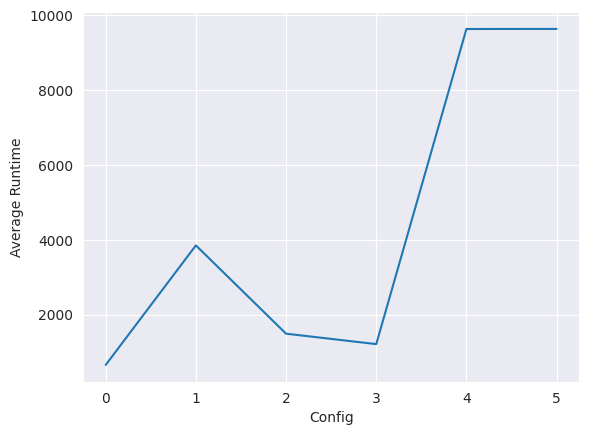

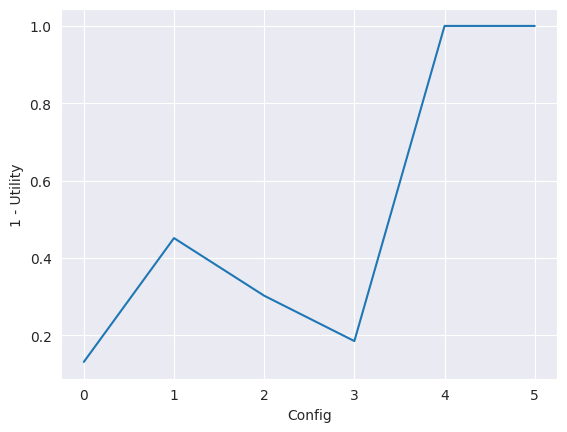

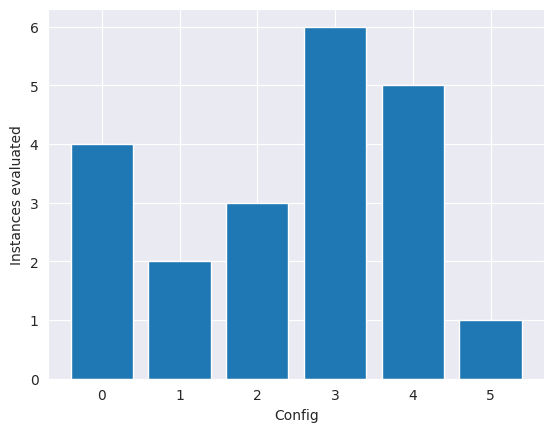

In [53]:
make_line_plot_over_time("./storage_alice/smac3_output/smac3_mipverify_utility_9600/0/")

So this is kinda a problem, as some really do need a new one, so maybe we should add th eidea of intesification with at least adding 1 to the currect incumbent as we can see that on the first 4 isntances the average is lower on config 4, but then it become hhigher because of a later instance.

In [54]:
def make_distance_plot(file_loc):

SyntaxError: incomplete input (2762519730.py, line 1)

In [62]:
def compare_encumbent_to_first(file_loc):
    hist, inten = read_json_file(file_loc)

    n_configs = len(hist["configs"])

    all_config_runtimes = {config_id:[] for config_id in range(1, n_configs+1)}
    all_config_cost = {config_id:[] for config_id in range(1, n_configs+1)}

    # Actually not compltely fair as we might compare 1 and 2 on 2 instances and then 1 wins, but later the average still becomes lower

    for run in hist["data"]:
        conf_id = run["config_id"]
        all_config_runtimes[conf_id].append(run["time"])
        all_config_cost[conf_id].append(run["cost"])

    incumbent_ids = inten["incumbent_ids"]
    first_encumbent = incumbent_ids[0]

    plt.scatter(all_config_runtimes[1], all_config_runtimes[int(first_encumbent)][:len(all_config_runtimes[1])], alpha=0.3, s=10)
    plt.xlabel("Runtime Default")
    plt.ylabel("Runtime Incumbent")
    plt.show()

    plt.scatter(all_config_cost[1], all_config_cost[int(first_encumbent)][:len(all_config_cost[1])],  alpha=0.3, s=10)
    plt.xlabel("Cost Default")
    plt.ylabel("Cost Incumbent")
    plt.show()

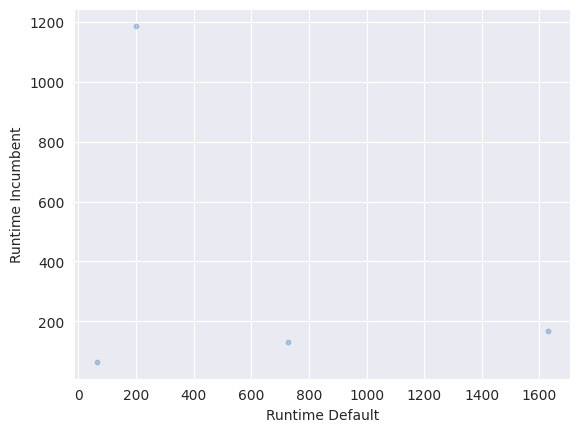

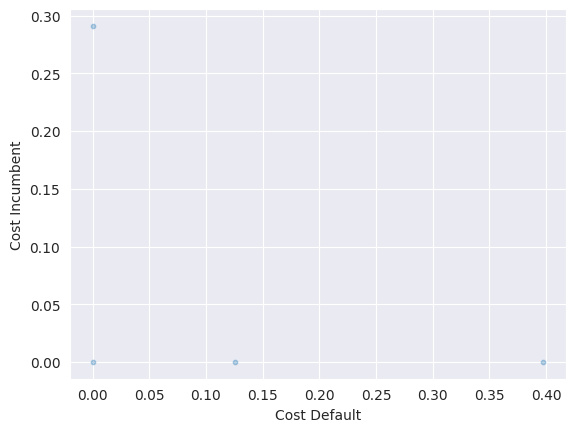

In [63]:
compare_encumbent_to_first("./storage_alice/smac3_output/smac3_mipverify_utility_9600/0/")

So there is definetly a very large difference somewhere in how smac3 compares to smac2 as it only uses 4 isntances here to make a decision instead of the (dont know how many) used in smac2.... Probably something to do with the decreased cutoffs somewhere is smac 2? but there is no clear documentation as to why this is the case? so smac2 would maybe be better, even though smac3 works as we expect it to work..

# 3600 captime utility


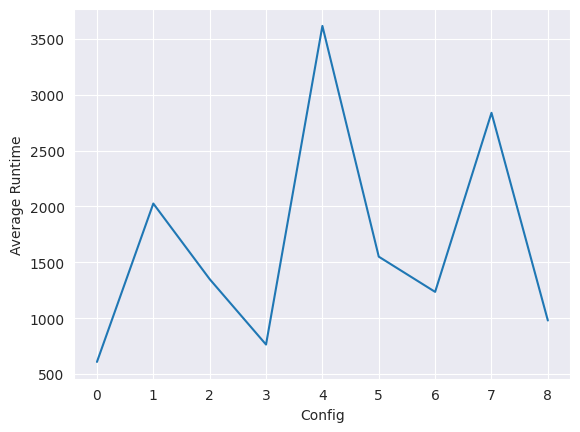

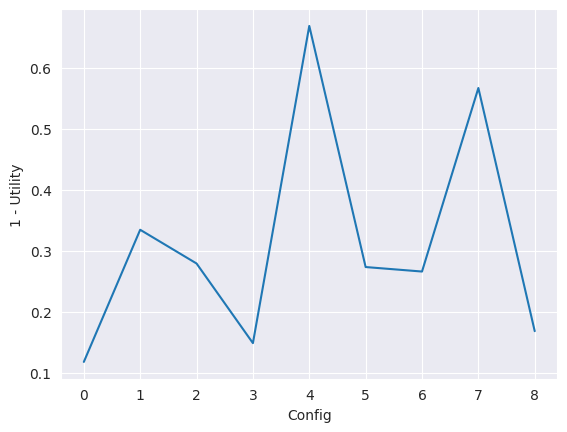

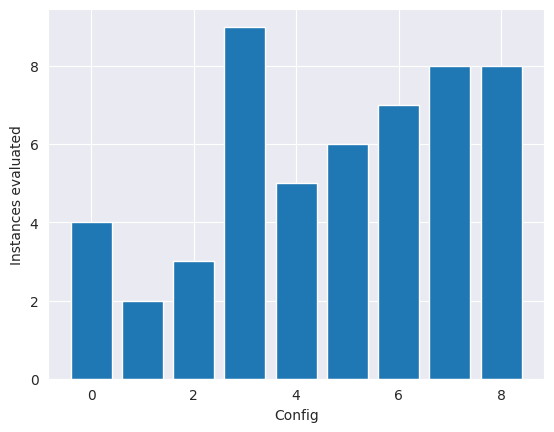

In [64]:
make_line_plot_over_time("./storage_alice/smac3_output/smac3_mipverify/0/")

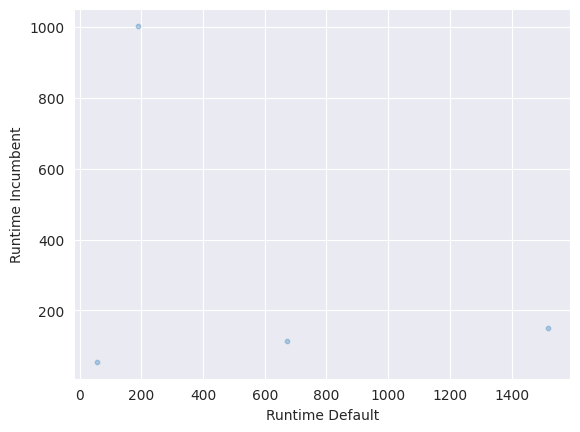

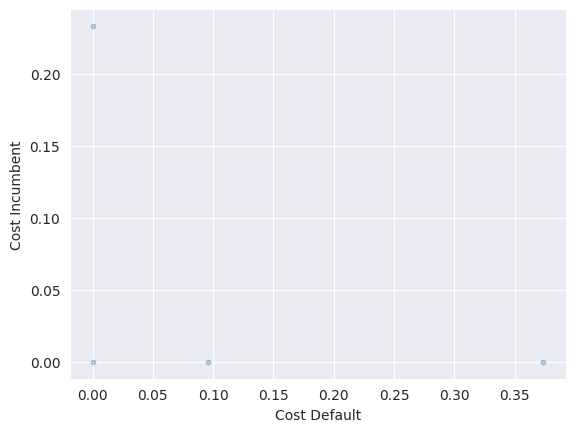

In [65]:
compare_encumbent_to_first("./storage_alice/smac3_output/smac3_mipverify/0/")

# 9600 captime Par

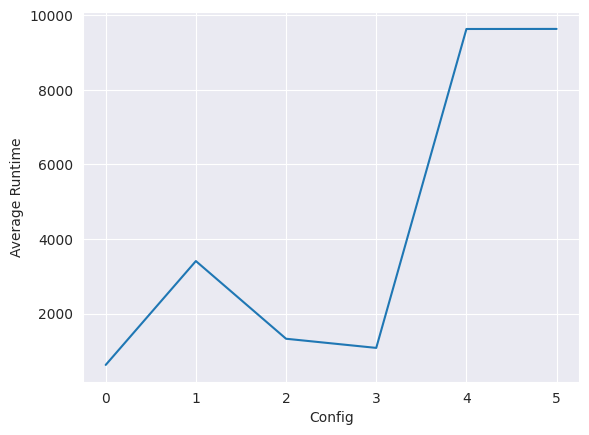

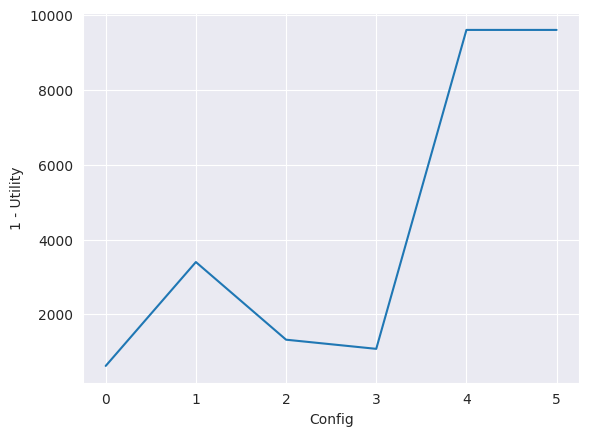

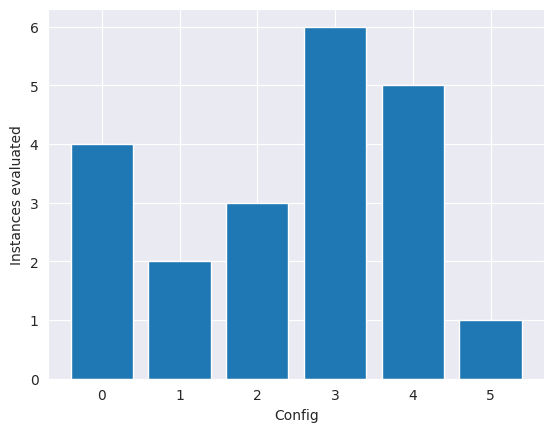

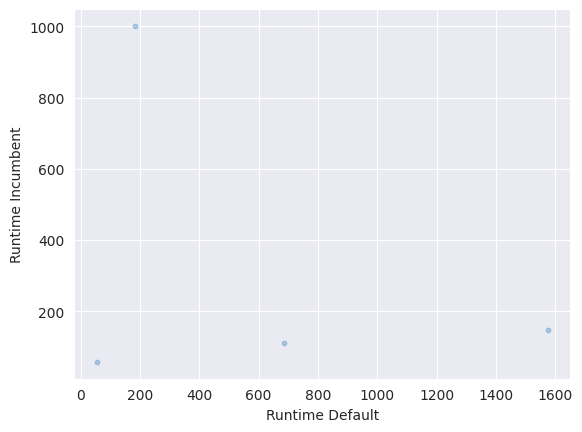

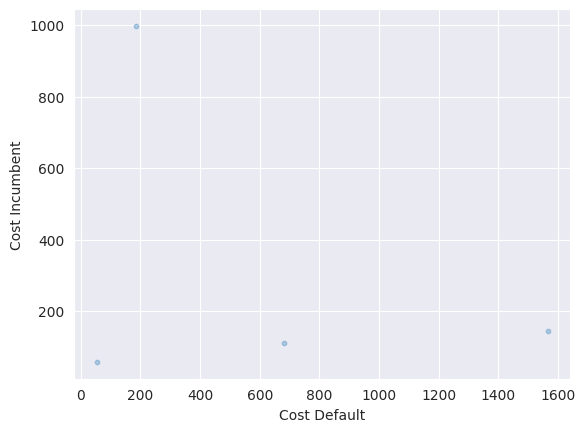

In [66]:
make_line_plot_over_time("./storage_alice/smac3_output/smac3_mipverify_par_run_cutoff9600/0/")
compare_encumbent_to_first("./storage_alice/smac3_output/smac3_mipverify_par_run_cutoff9600/0/")

# 3600 Captime PAR

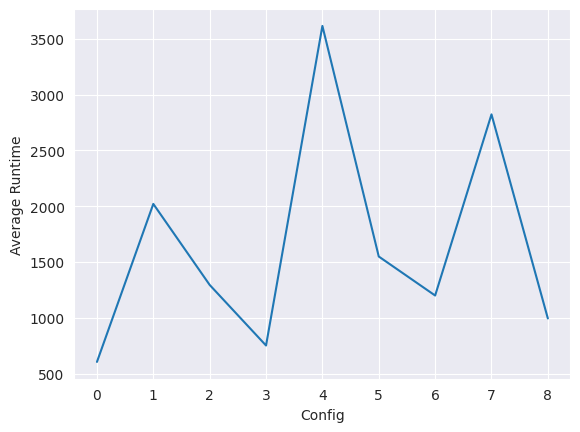

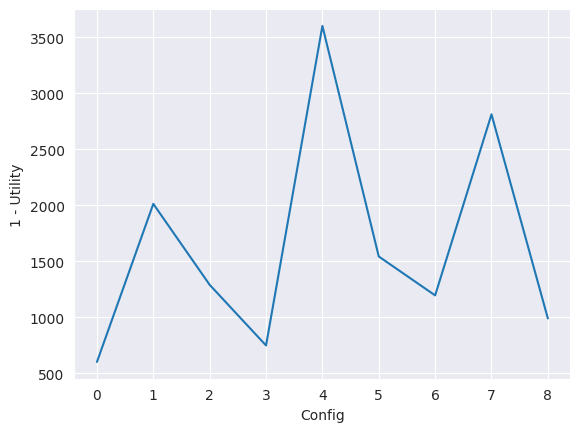

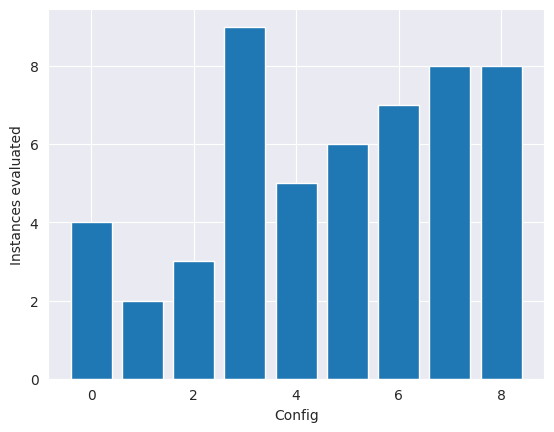

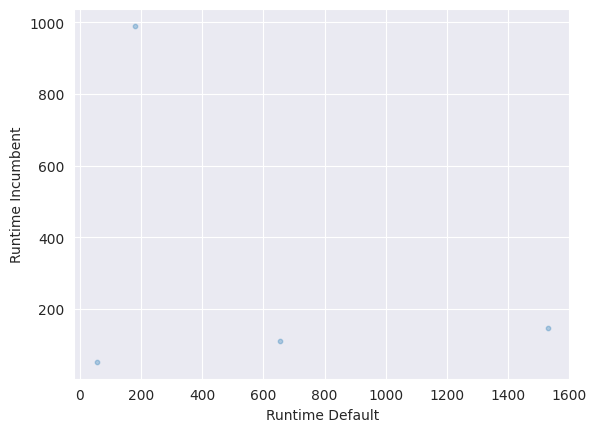

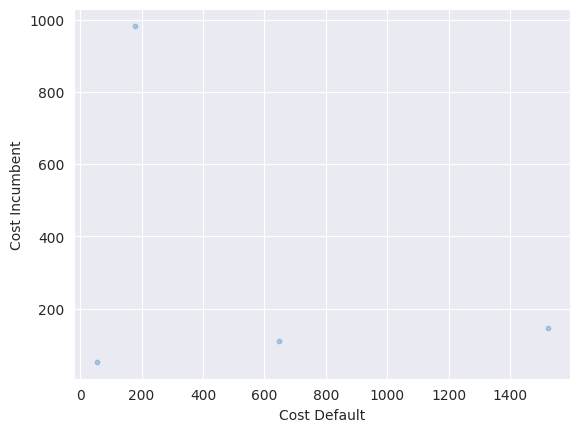

In [67]:
make_line_plot_over_time("./storage_alice/smac3_output/smac3_mipverify_par_run_cutoff3600/0/")
compare_encumbent_to_first("./storage_alice/smac3_output/smac3_mipverify_par_run_cutoff3600/0/")